In [2]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import sys
!{sys.executable} -m pip install pycountry

In [4]:
import pycountry

# Import both datasets

In [5]:
covid_df = pd.read_parquet('../data/processed/covid_cleaned.csv')

In [6]:
covid_df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,New_cases_clean,New_deaths_clean
0,2021-01-31,AI,Anguilla,AMRO,2.0,17,NaN,0,2.0,NaN
1,2021-02-07,AI,Anguilla,AMRO,NaN,17,NaN,0,2.0,NaN
2,2021-02-14,AI,Anguilla,AMRO,1.0,18,NaN,0,1.0,NaN
3,2021-02-21,AI,Anguilla,AMRO,NaN,18,NaN,0,1.0,NaN
4,2021-01-31,AW,Aruba,AMRO,235.0,6858,6.0,58,235.0,6.0


In [7]:
covid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36720 entries, 0 to 36719
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Date_reported      36720 non-null  datetime64[ns]
 1   Country_code       36720 non-null  object        
 2   Country            36720 non-null  object        
 3   WHO_region         36720 non-null  object        
 4   New_cases          29543 non-null  float64       
 5   Cumulative_cases   36720 non-null  int64         
 6   New_deaths         22587 non-null  float64       
 7   Cumulative_deaths  36720 non-null  int64         
 8   New_cases_clean    36425 non-null  float64       
 9   New_deaths_clean   35125 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(3)
memory usage: 2.8+ MB


In [8]:
vaccines_df = pd.read_parquet('../data/processed/vaccines_cleaned.csv')

In [9]:
vaccines_df.head()

,Country_code,Covid_Vaccine_Adm_Tot_A1D,Covid_Vaccine_Adm_Tot_Boost,Covid_Vaccine_Adm_Tot_Cps,Covid_Vaccine_Adm_Tot_Doses,Covid_Vaccine_Adm_Tot_Doses_Per100,Covid_Vaccine_Cov_Tot_A1D,Covid_Vaccine_Cov_Tot_Boost,Covid_Vaccine_Cov_Tot_Cps,Covid_Vaccine_Date_Intro_First,Covid_Vaccine_Date_Report_Tot_Last,Date_reported
0,ABW,4606.0,NaN,NaN,4606.0,4.0,4.0,NaN,NaN,2021-02-17,2023-12-29,2021-02-28
1,ABW,16768.0,NaN,10086.0,26854.0,25.0,16.0,NaN,9.0,2021-02-17,2023-12-29,2021-03-28
2,ABW,53837.0,NaN,20910.0,74747.0,70.0,50.0,NaN,20.0,2021-02-17,2023-12-29,2021-04-25
3,ABW,62980.0,NaN,50725.0,113706.0,107.0,59.0,NaN,48.0,2021-02-17,2023-12-29,2021-05-30
4,ABW,67601.0,NaN,58865.0,126466.0,118.0,63.0,NaN,55.0,2021-02-17,2023-12-29,2021-06-27


In [10]:
vaccines_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7608 entries, 0 to 7607
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Country_code                        7608 non-null   object        
 1   Covid_Vaccine_Adm_Tot_A1D           7329 non-null   float64       
 2   Covid_Vaccine_Adm_Tot_Boost         4830 non-null   float64       
 3   Covid_Vaccine_Adm_Tot_Cps           7101 non-null   float64       
 4   Covid_Vaccine_Adm_Tot_Doses         7426 non-null   float64       
 5   Covid_Vaccine_Adm_Tot_Doses_Per100  7199 non-null   float64       
 6   Covid_Vaccine_Cov_Tot_A1D           7112 non-null   float64       
 7   Covid_Vaccine_Cov_Tot_Boost         4403 non-null   float64       
 8   Covid_Vaccine_Cov_Tot_Cps           6803 non-null   float64       
 9   Covid_Vaccine_Date_Intro_First      6807 non-null   datetime64[ns]
 10  Covid_Vaccine_Date_Repor

In [11]:
def alpha3_to_alpha2(code):
    if pd.isna(code):
        return np.nan
    
    try:
        return pycountry.countries.get(alpha_3=code).alpha_2
    except:
        return np.nan

vaccines_df["Country_code"] = vaccines_df["Country_code"].apply(alpha3_to_alpha2)

In [12]:
vaccines_df.head()

,Country_code,Covid_Vaccine_Adm_Tot_A1D,Covid_Vaccine_Adm_Tot_Boost,Covid_Vaccine_Adm_Tot_Cps,Covid_Vaccine_Adm_Tot_Doses,Covid_Vaccine_Adm_Tot_Doses_Per100,Covid_Vaccine_Cov_Tot_A1D,Covid_Vaccine_Cov_Tot_Boost,Covid_Vaccine_Cov_Tot_Cps,Covid_Vaccine_Date_Intro_First,Covid_Vaccine_Date_Report_Tot_Last,Date_reported
0,AW,4606.0,NaN,NaN,4606.0,4.0,4.0,NaN,NaN,2021-02-17,2023-12-29,2021-02-28
1,AW,16768.0,NaN,10086.0,26854.0,25.0,16.0,NaN,9.0,2021-02-17,2023-12-29,2021-03-28
2,AW,53837.0,NaN,20910.0,74747.0,70.0,50.0,NaN,20.0,2021-02-17,2023-12-29,2021-04-25
3,AW,62980.0,NaN,50725.0,113706.0,107.0,59.0,NaN,48.0,2021-02-17,2023-12-29,2021-05-30
4,AW,67601.0,NaN,58865.0,126466.0,118.0,63.0,NaN,55.0,2021-02-17,2023-12-29,2021-06-27


In [13]:
vaccine_df = vaccines_df.sort_values(["Country_code", "Date_reported"])

vaccines_weekly = (
    vaccines_df
    .sort_values(["Country_code", "Date_reported"])
    .groupby("Country_code", group_keys=False)
    .apply(lambda x: x.set_index("Date_reported").resample("W").ffill())
    .reset_index()
)

/var/folders/r4/jsr6jl3d5js8g1ztlswntdr80000gp/T/ipykernel_9860/356345992.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.set_index("Date_reported").resample("W").ffill())


In [15]:
covid_df["Date_reported"] = pd.to_datetime(covid_df["Date_reported"])
vaccines_weekly["Date_reported"] = pd.to_datetime(vaccines_weekly["Date_reported"])

final_df = pd.merge(
    covid_df,
    vaccines_weekly,
    on=["Country_code", "Date_reported"],
    how="left"
)

In [16]:
final_df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,New_cases_clean,New_deaths_clean,Covid_Vaccine_Adm_Tot_A1D,Covid_Vaccine_Adm_Tot_Boost,Covid_Vaccine_Adm_Tot_Cps,Covid_Vaccine_Adm_Tot_Doses,Covid_Vaccine_Adm_Tot_Doses_Per100,Covid_Vaccine_Cov_Tot_A1D,Covid_Vaccine_Cov_Tot_Boost,Covid_Vaccine_Cov_Tot_Cps,Covid_Vaccine_Date_Intro_First,Covid_Vaccine_Date_Report_Tot_Last
0,2021-01-31,AI,Anguilla,AMRO,2.0,17,NaN,0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
1,2021-02-07,AI,Anguilla,AMRO,NaN,17,NaN,0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
2,2021-02-14,AI,Anguilla,AMRO,1.0,18,NaN,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
3,2021-02-21,AI,Anguilla,AMRO,NaN,18,NaN,0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT
4,2021-01-31,AW,Aruba,AMRO,235.0,6858,6.0,58,235.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaT


In [17]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36720 entries, 0 to 36719
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Date_reported                       36720 non-null  datetime64[ns]
 1   Country_code                        36720 non-null  object        
 2   Country                             36720 non-null  object        
 3   WHO_region                          36720 non-null  object        
 4   New_cases                           29543 non-null  float64       
 5   Cumulative_cases                    36720 non-null  int64         
 6   New_deaths                          22587 non-null  float64       
 7   Cumulative_deaths                   36720 non-null  int64         
 8   New_cases_clean                     36425 non-null  float64       
 9   New_deaths_clean                    35125 non-null  float64       
 10  Covid_Vaccine_Adm_Tot_

In [18]:
final_df.isna().sum()/len(final_df)*100

Date_reported                          0.000000
Country_code                           0.000000
Country                                0.000000
WHO_region                             0.000000
New_cases                             19.545207
Cumulative_cases                       0.000000
New_deaths                            38.488562
Cumulative_deaths                      0.000000
New_cases_clean                        0.803377
New_deaths_clean                       4.343682
Covid_Vaccine_Adm_Tot_A1D             15.433007
Covid_Vaccine_Adm_Tot_Boost           44.820261
Covid_Vaccine_Adm_Tot_Cps             18.071895
Covid_Vaccine_Adm_Tot_Doses           14.340959
Covid_Vaccine_Adm_Tot_Doses_Per100    16.922658
Covid_Vaccine_Cov_Tot_A1D             17.916667
Covid_Vaccine_Cov_Tot_Boost           49.757625
Covid_Vaccine_Cov_Tot_Cps             21.541394
Covid_Vaccine_Date_Intro_First        21.476035
Covid_Vaccine_Date_Report_Tot_Last    14.923747
dtype: float64

In [20]:
final_df['Country_code'].unique()

array(['AI', 'AW', 'AF', 'AM', 'AO', 'AE', 'AL', 'AT', 'AD', 'AZ', 'AG',
       'BI', 'AR', 'BD', 'BA', 'BE', 'AS', 'BH', 'BL', 'BQ', 'AU', 'BS',
       'BT', 'BF', 'BJ', 'BR', 'CH', 'BG', 'BY', 'BB', 'CL', 'BZ', 'BM',
       'CA', 'CN', 'BN', 'CK', 'BO', 'BW', 'CO', 'CI', 'CD', 'KM', 'CF',
       'DJ', 'CM', 'CG', 'CR', 'DK', 'CU', 'CV', 'CW', 'DZ', 'EC', 'CY',
       'KY', 'FR', 'EG', 'CZ', 'FM', 'DE', 'EE', 'ER', 'GR', 'DM', 'FJ',
       'FI', 'GD', 'DO', 'FO', 'GG', 'GF', 'ES', 'GH', 'GB', 'GU', 'ET',
       'GI', 'GE', 'FK', 'IL', 'GM', 'GN', 'GY', 'GA', 'JE', 'GQ', 'GP',
       'HU', 'JP', 'GT', 'GW', 'ID', 'KH', 'HT', 'GL', 'IS', 'KN', 'JM',
       'HN', 'IT', 'KR', 'KI', 'KE', 'HR', 'KW', 'LA', 'LC', 'IM', 'LR',
       'MA', 'IN', 'LI', 'LY', 'MC', 'MV', 'IE', 'MH', 'MG', 'MX', 'IR',
       'MN', 'MK', 'IQ', 'MQ', 'MS', 'ML', 'JO', 'NG', 'MT', 'MU', 'KZ',
       'NZ', 'MM', 'YT', 'KG', 'PE', 'ME', 'LB', 'NA', 'PG', 'MP', 'LK',
       'NI', 'PL', 'MR', 'LS', 'NO', 'NC', 'KP', 'L

In [21]:
invalid_codes = ['XXF', 'XXG', 'XXH', 'XXJ', 'XXI', 'XXL']
final_df = final_df[~final_df['Country_code'].isin(invalid_codes)]

In [24]:
final_df['Country_code'].unique()

array(['AI', 'AW', 'AF', 'AM', 'AO', 'AE', 'AL', 'AT', 'AD', 'AZ', 'AG',
       'BI', 'AR', 'BD', 'BA', 'BE', 'AS', 'BH', 'BL', 'BQ', 'AU', 'BS',
       'BT', 'BF', 'BJ', 'BR', 'CH', 'BG', 'BY', 'BB', 'CL', 'BZ', 'BM',
       'CA', 'CN', 'BN', 'CK', 'BO', 'BW', 'CO', 'CI', 'CD', 'KM', 'CF',
       'DJ', 'CM', 'CG', 'CR', 'DK', 'CU', 'CV', 'CW', 'DZ', 'EC', 'CY',
       'KY', 'FR', 'EG', 'CZ', 'FM', 'DE', 'EE', 'ER', 'GR', 'DM', 'FJ',
       'FI', 'GD', 'DO', 'FO', 'GG', 'GF', 'ES', 'GH', 'GB', 'GU', 'ET',
       'GI', 'GE', 'FK', 'IL', 'GM', 'GN', 'GY', 'GA', 'JE', 'GQ', 'GP',
       'HU', 'JP', 'GT', 'GW', 'ID', 'KH', 'HT', 'GL', 'IS', 'KN', 'JM',
       'HN', 'IT', 'KR', 'KI', 'KE', 'HR', 'KW', 'LA', 'LC', 'IM', 'LR',
       'MA', 'IN', 'LI', 'LY', 'MC', 'MV', 'IE', 'MH', 'MG', 'MX', 'IR',
       'MN', 'MK', 'IQ', 'MQ', 'MS', 'ML', 'JO', 'NG', 'MT', 'MU', 'KZ',
       'NZ', 'MM', 'YT', 'KG', 'PE', 'ME', 'LB', 'NA', 'PG', 'MP', 'LK',
       'NI', 'PL', 'MR', 'LS', 'NO', 'NC', 'KP', 'L

Some non-standard country codes (e.g., 'XXF', 'XXG', etc.) were identified, representing undefined or aggregated regions. These were removed to ensure consistency and analytical validity. Standard ISO alpha-2 country codes were retained, including special cases such as 'XK' (Kosovo).

# Final dataset overview

In [32]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35802 entries, 0 to 36413
Data columns (total 20 columns):
 #   Column                              Non-Null Count  Dtype         
---  ------                              --------------  -----         
 0   Date_reported                       35802 non-null  datetime64[ns]
 1   Country_code                        35802 non-null  object        
 2   Country                             35802 non-null  object        
 3   WHO_region                          35802 non-null  object        
 4   New_cases                           29539 non-null  float64       
 5   Cumulative_cases                    35802 non-null  int64         
 6   New_deaths                          22587 non-null  float64       
 7   Cumulative_deaths                   35802 non-null  int64         
 8   New_cases_clean                     35548 non-null  float64       
 9   New_deaths_clean                    34972 non-null  float64       
 10  Covid_Vaccine_Adm_Tot_A1D  

In [33]:
final_df.shape

(35802, 20)

In [34]:
final_df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date_reported,35802,2022-07-17 00:00:00,2021-01-31 00:00:00,2021-10-24 00:00:00,2022-07-17 00:00:00,2023-04-09 00:00:00,2023-12-31 00:00:00,NaN
New_cases,29539.0,22856.120011,-65079.0,31.0,373.0,4279.0,40475477.0,309353.210277
Cumulative_cases,35802.0,2162908.772946,0.0,15367.0,113265.0,912321.25,103436829.0,8311564.79381
New_deaths,22587.0,209.562713,-3432.0,1.0,9.0,68.0,47687.0,1080.999527
Cumulative_deaths,35802.0,24839.346657,0.0,126.0,1359.0,10078.0,1164497.0,90400.698897
New_cases_clean,35548.0,19210.08113,-65079.0,17.0,226.0,2900.25,40475477.0,282128.720054
New_deaths_clean,34972.0,137.353111,-3432.0,1.0,2.0,26.0,47687.0,874.351985
Covid_Vaccine_Adm_Tot_A1D,31053.0,21141011.538048,11.0,191403.0,1955740.0,8036859.0,1318026807.0,104929449.263038
Covid_Vaccine_Adm_Tot_Boost,20262.0,10959121.774652,1.0,43068.0,599613.0,4365778.0,834060133.0,58207358.268449
Covid_Vaccine_Adm_Tot_Cps,30084.0,18988809.106768,2.0,162250.0,1438154.0,6887725.25,1284479582.0,98435655.82141


### Missing values

In [35]:
missing = final_df.isna().mean().sort_values(ascending=False)
missing

Covid_Vaccine_Cov_Tot_Boost           0.484694
Covid_Vaccine_Adm_Tot_Boost           0.434054
New_deaths                            0.369113
Covid_Vaccine_Cov_Tot_Cps             0.195296
Covid_Vaccine_Date_Intro_First        0.194626
New_cases                             0.174934
Covid_Vaccine_Adm_Tot_Cps             0.159712
Covid_Vaccine_Cov_Tot_A1D             0.158120
Covid_Vaccine_Adm_Tot_Doses_Per100    0.147925
Covid_Vaccine_Adm_Tot_A1D             0.132646
Covid_Vaccine_Date_Report_Tot_Last    0.127423
Covid_Vaccine_Adm_Tot_Doses           0.121446
New_deaths_clean                      0.023183
New_cases_clean                       0.007095
Country_code                          0.000000
Date_reported                         0.000000
WHO_region                            0.000000
Country                               0.000000
Cumulative_cases                      0.000000
Cumulative_deaths                     0.000000
dtype: float64

In [25]:
final_df.isna().sum()/len(final_df)*100

Date_reported                          0.000000
Country_code                           0.000000
Country                                0.000000
WHO_region                             0.000000
New_cases                             17.493436
Cumulative_cases                       0.000000
New_deaths                            36.911346
Cumulative_deaths                      0.000000
New_cases_clean                        0.709458
New_deaths_clean                       2.318306
Covid_Vaccine_Adm_Tot_A1D             13.264622
Covid_Vaccine_Adm_Tot_Boost           43.405396
Covid_Vaccine_Adm_Tot_Cps             15.971175
Covid_Vaccine_Adm_Tot_Doses           12.144573
Covid_Vaccine_Adm_Tot_Doses_Per100    14.792470
Covid_Vaccine_Cov_Tot_A1D             15.811966
Covid_Vaccine_Cov_Tot_Boost           48.469359
Covid_Vaccine_Cov_Tot_Cps             19.529635
Covid_Vaccine_Date_Intro_First        19.462600
Covid_Vaccine_Date_Report_Tot_Last    12.742305
dtype: float64

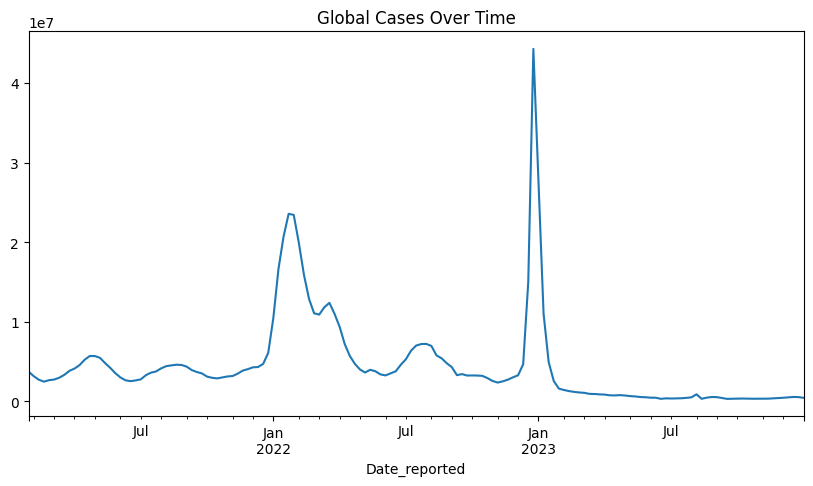

In [41]:
final_df.groupby("Date_reported")["New_cases_clean"].sum().plot(figsize=(10,5), title="Global Cases Over Time")
plt.show()

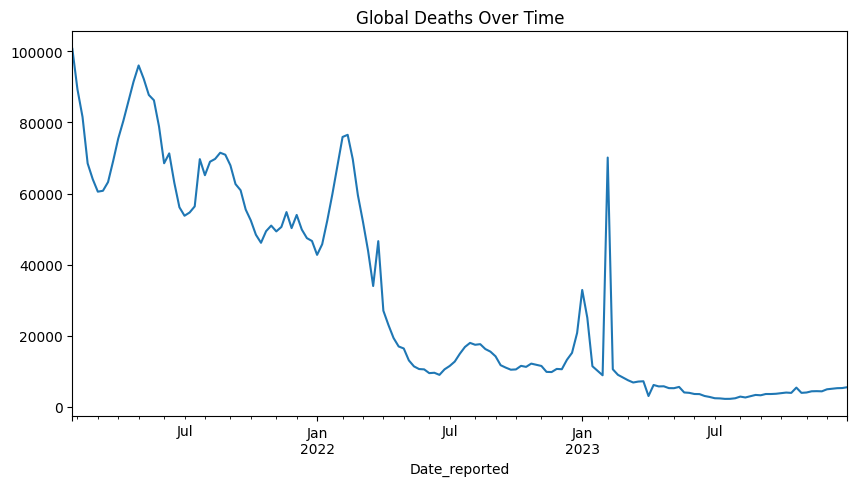

In [43]:
final_df.groupby("Date_reported")["New_deaths_clean"].sum().plot(figsize=(10,5), title="Global Deaths Over Time")
plt.show()

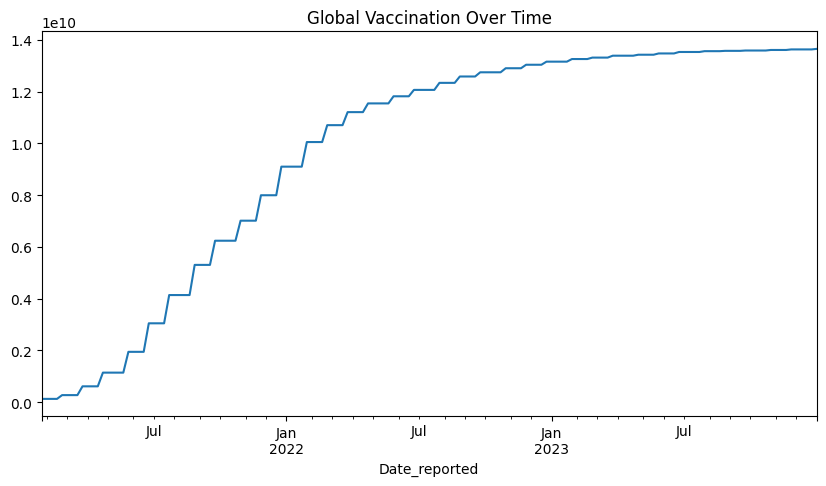

In [44]:
final_df.groupby("Date_reported")["Covid_Vaccine_Adm_Tot_Doses"].sum().plot(figsize=(10,5), title="Global Vaccination Over Time")
plt.show()

In [46]:
us_df = final_df[final_df['Country_code'] == 'US']
us_df.head()

,Date_reported,Country_code,Country,WHO_region,New_cases,Cumulative_cases,New_deaths,Cumulative_deaths,New_cases_clean,New_deaths_clean,Covid_Vaccine_Adm_Tot_A1D,Covid_Vaccine_Adm_Tot_Boost,Covid_Vaccine_Adm_Tot_Cps,Covid_Vaccine_Adm_Tot_Doses,Covid_Vaccine_Adm_Tot_Doses_Per100,Covid_Vaccine_Cov_Tot_A1D,Covid_Vaccine_Cov_Tot_Boost,Covid_Vaccine_Cov_Tot_Cps,Covid_Vaccine_Date_Intro_First,Covid_Vaccine_Date_Report_Tot_Last
30555,2021-01-31,US,United States of America,AMRO,1068625.0,25863033,22249.0,452123,1068625.0,22249.0,23471918.0,NaN,5023911.0,28767976.0,9.0,7.0,NaN,2.0,2020-12-14,2023-12-29
30556,2021-02-07,US,United States of America,AMRO,857250.0,26720283,20100.0,472223,857250.0,20100.0,23471918.0,NaN,5023911.0,28767976.0,9.0,7.0,NaN,2.0,2020-12-14,2023-12-29
30557,2021-02-14,US,United States of America,AMRO,670572.0,27390855,19838.0,492061,670572.0,19838.0,23471918.0,NaN,5023911.0,28767976.0,9.0,7.0,NaN,2.0,2020-12-14,2023-12-29
30558,2021-02-21,US,United States of America,AMRO,473485.0,27864340,14432.0,506493,473485.0,14432.0,23471918.0,NaN,5023911.0,28767976.0,9.0,7.0,NaN,2.0,2020-12-14,2023-12-29
30559,2021-02-28,US,United States of America,AMRO,465751.0,28330091,13360.0,519853,465751.0,13360.0,49141762.0,NaN,24094108.0,73916574.0,22.0,15.0,NaN,7.0,2020-12-14,2023-12-29


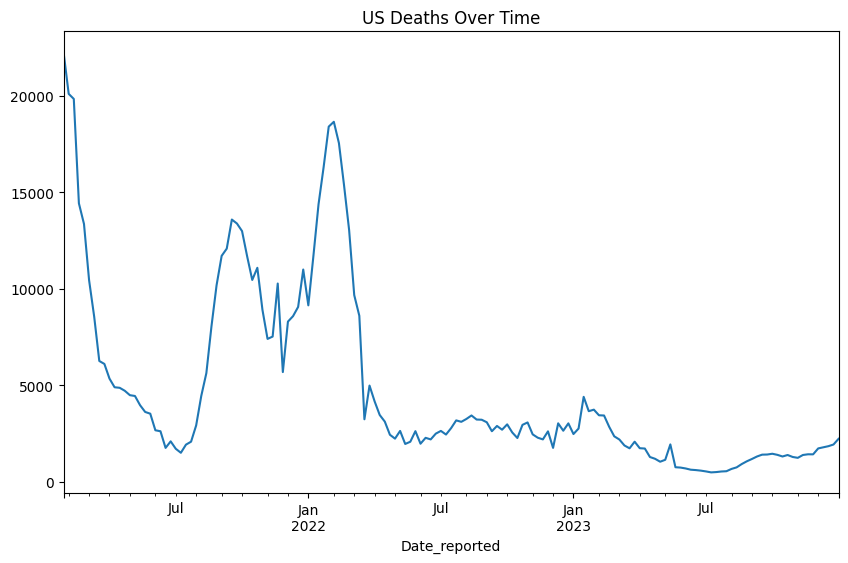

In [47]:
us_df.groupby('Date_reported')['New_deaths_clean'].sum().plot(figsize=(10, 6), title='US Deaths Over Time')
plt.show()

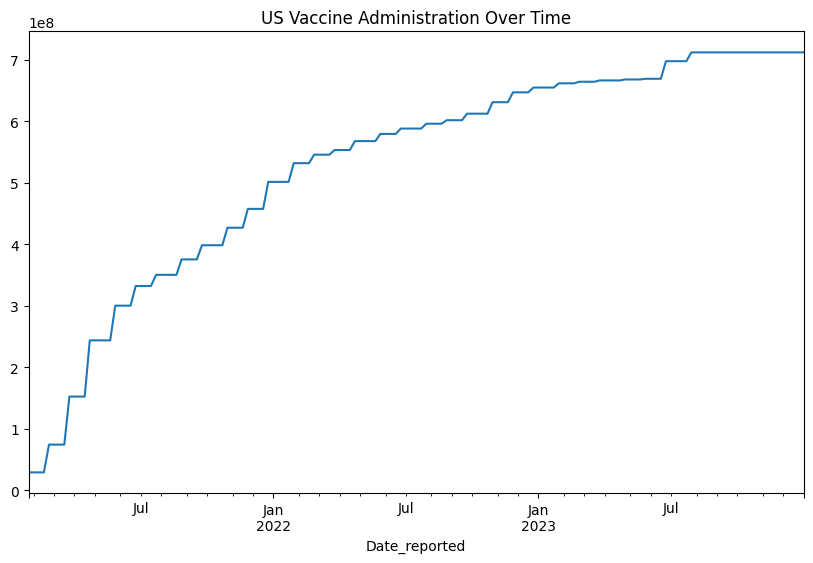

In [48]:
us_df.groupby('Date_reported')['Covid_Vaccine_Adm_Tot_Doses'].sum().plot(figsize=(10, 6), title='US Vaccine Administration Over Time')
plt.show()

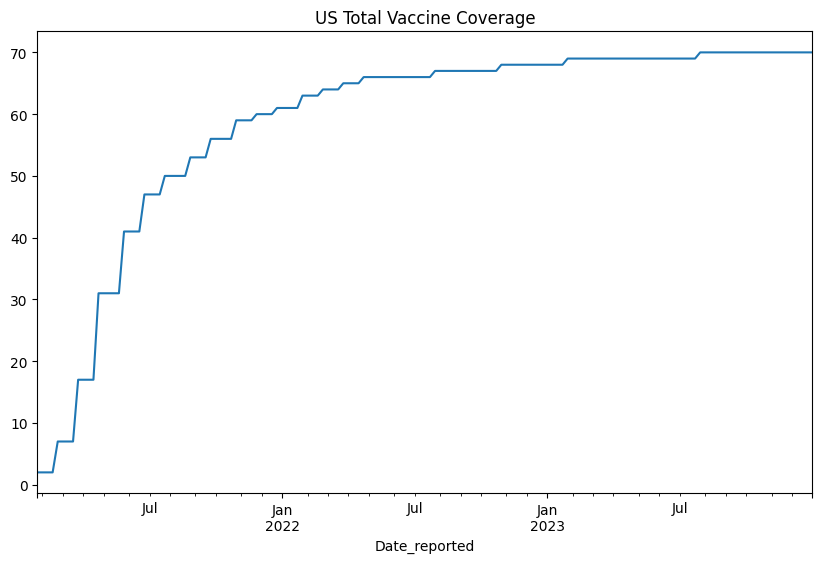

In [50]:
us_df.groupby('Date_reported')['Covid_Vaccine_Cov_Tot_Cps'].sum().plot(figsize=(10, 6), title="US Total Vaccine Coverage")
plt.show()

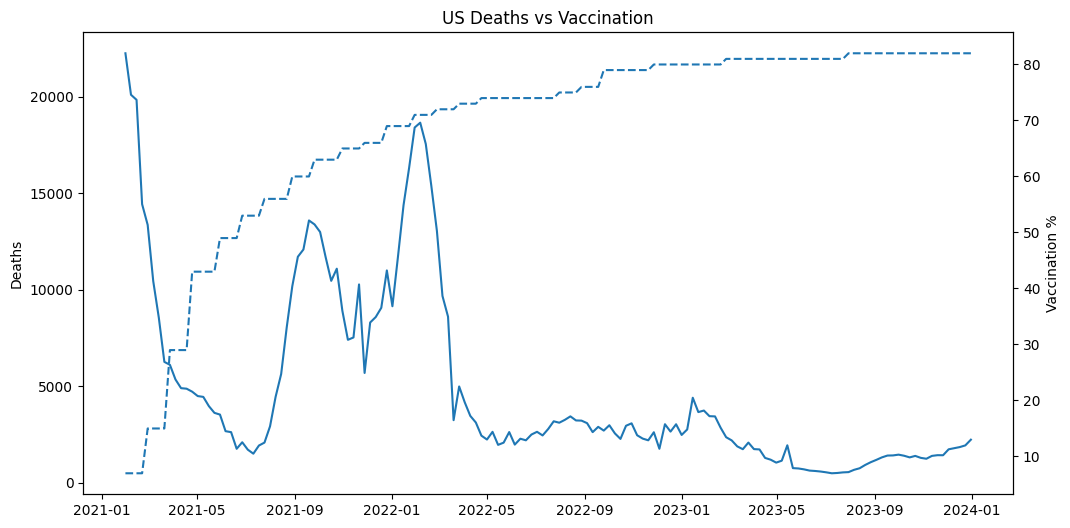

In [51]:
fig, ax1 = plt.subplots(figsize=(12,6))

ax1.plot(us_df["Date_reported"], us_df["New_deaths_clean"], label="Deaths")
ax1.set_ylabel("Deaths")

ax2 = ax1.twinx()
ax2.plot(us_df["Date_reported"], us_df["Covid_Vaccine_Cov_Tot_A1D"], linestyle="--", label="Vaccination (%)")
ax2.set_ylabel("Vaccination %")

plt.title("US Deaths vs Vaccination")
plt.show()